# Sentiment Analysis on Movie Reviews
### Comparing Classical Machine Learning Algorithms (Rotten Tomatoes Phrase Dataset)

This notebook builds and compares several classical ML algorithms for 5-class sentiment classification
(0 = negative, 1 = somewhat negative, 2 = neutral, 3 = somewhat positive, 4 = positive) on the
Kaggle "Sentiment Analysis on Movie Reviews" dataset (Rotten Tomatoes phrases).

**Goal:** maximize validation accuracy while comparing algorithm behavior, training cost, and error patterns.

**Note on scope:** A transformer-based model (e.g. BERT) would likely beat these classical baselines, but
fine-tuning BERT requires GPU compute and downloading pretrained weights, which isn't available in this
environment. This notebook focuses on a rigorous, fully-executed comparison of classical ML approaches.


## 1. Setup & Data Loading

In [9]:
import pandas as pd
import numpy as np
import time
import json
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

RANDOM_STATE = 42


In [10]:
train = pd.read_csv('train.tsv', sep='\t')
test = pd.read_csv('test.tsv', sep='\t')

# A handful of phrases can be empty strings/whitespace, which pandas reads as NaN.
# Replace with empty string so the vectorizer can still handle them as valid (zero-signal) documents.
train['Phrase'] = train['Phrase'].fillna('')
test['Phrase'] = test['Phrase'].fillna('')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()


Train shape: (156060, 4)
Test shape: (66292, 3)


,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


## 2. Exploratory Data Analysis

The dataset labels individual **phrases** (sub-spans of sentences from Rotten Tomatoes reviews) on a 5-point
sentiment scale. Because many phrases are sub-phrases of the same sentence, we must split train/validation
data **by `SentenceId`**, not by row, to avoid leaking near-duplicate phrases between train and validation sets.

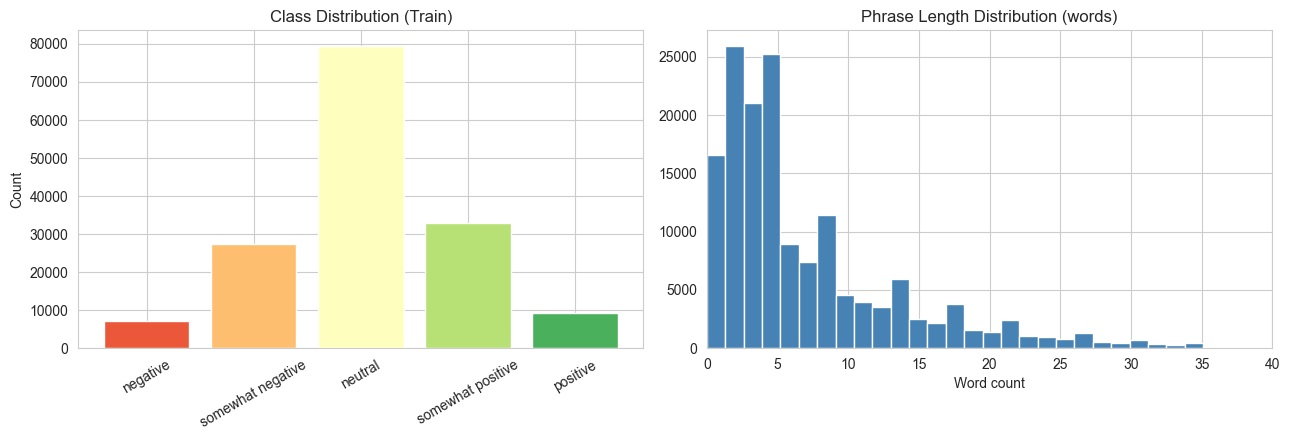

Sentiment
0     7072
1    27273
2    79582
3    32927
4     9206
Name: count, dtype: int64

Class imbalance: 'neutral' (2) is 11.3 x more frequent than 'negative' (0)


In [11]:
label_map = {0: "negative", 1: "somewhat negative", 2: "neutral", 3: "somewhat positive", 4: "positive"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sentiment_counts = train['Sentiment'].value_counts().sort_index()
axes[0].bar([label_map[i] for i in sentiment_counts.index], sentiment_counts.values, color=sns.color_palette("RdYlGn", 5))
axes[0].set_title("Class Distribution (Train)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)

phrase_lengths = train['Phrase'].astype(str).apply(lambda x: len(x.split()))
axes[1].hist(phrase_lengths, bins=40, color="steelblue")
axes[1].set_title("Phrase Length Distribution (words)")
axes[1].set_xlabel("Word count")
axes[1].set_xlim(0, 40)

plt.tight_layout()
plt.show()

print(sentiment_counts)
print("\nClass imbalance: 'neutral' (2) is", round(sentiment_counts[2] / sentiment_counts[0], 1), "x more frequent than 'negative' (0)")


In [12]:
import os

print("Current folder:", os.getcwd())
print("\nFiles in current folder:")
print(os.listdir())

Current folder: /Users/mac/Downloads/sentiment-analysis-movie-reviews/notebooks

Files in current folder:
['train.tsv', 'Sentiment_Analysis_Movie_Reviews.ipynb', 'test.tsv']


**Observations:**
- The dataset is **imbalanced**: class 2 (neutral) dominates (~51% of rows), while classes 0 and 4
  (strong negative/positive) are rare (~5-6% each). This is because every sub-phrase of a sentence is
  also labeled, and short/neutral sub-phrases (single words, stopwords) are common.
- Most phrases are short (many are single words or short spans), which makes this a harder task than
  sentence-level sentiment analysis — short phrases carry less context.
- Accuracy alone can be misleading here; we'll also look at the confusion matrix and per-class F1.

## 3. Train / Validation Split (by SentenceId, to prevent leakage)

In [13]:
sentence_ids = train['SentenceId'].unique()
train_ids, val_ids = train_test_split(sentence_ids, test_size=0.2, random_state=RANDOM_STATE)

train_df = train[train['SentenceId'].isin(train_ids)].reset_index(drop=True)
val_df = train[train['SentenceId'].isin(val_ids)].reset_index(drop=True)

X_train_text, y_train = train_df['Phrase'].astype(str), train_df['Sentiment']
X_val_text, y_val = val_df['Phrase'].astype(str), val_df['Sentiment']

print("Train phrases:", len(train_df), " | Val phrases:", len(val_df))


Train phrases: 125212  | Val phrases: 30848


## 4. Feature Engineering — TF-IDF

We use TF-IDF with unigrams + bigrams, sublinear term-frequency scaling, and a vocabulary cap to keep
training fast while capturing short negation/intensifier patterns (e.g. "not good", "very bad") that
matter a lot for sentiment.

In [14]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)
X_train = tfidf.fit_transform(X_train_text)
X_val = tfidf.transform(X_val_text)

print("TF-IDF matrix shape (train):", X_train.shape)
print("TF-IDF matrix shape (val):  ", X_val.shape)


TF-IDF matrix shape (train): (125212, 20000)
TF-IDF matrix shape (val):   (30848, 20000)


## 5. Model Training & Comparison

We train four classical algorithms on identical TF-IDF features so the comparison is apples-to-apples:

- **Multinomial Naive Bayes** — fast probabilistic baseline, strong for text classification
- **Logistic Regression** — linear model, regularized, often very competitive on sparse TF-IDF features
- **Linear SVM** (`LinearSVC`) — margin-based linear classifier, typically among the best for high-dimensional sparse text
- **Random Forest** — non-linear ensemble baseline, included for contrast (trees generally don't suit sparse high-dim TF-IDF as well)


In [15]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, C=10, random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(C=0.5, max_iter=3000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=40, n_jobs=-1, random_state=RANDOM_STATE),
}

results = {}
predictions = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0

    preds = model.predict(X_val)
    predictions[name] = preds

    acc = accuracy_score(y_val, preds)
    macro_f1 = f1_score(y_val, preds, average="macro")
    weighted_f1 = f1_score(y_val, preds, average="weighted")

    results[name] = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "train_time_sec": elapsed,
    }
    print(f"{name:22s} | acc={acc:.4f} | macro-F1={macro_f1:.4f} | weighted-F1={weighted_f1:.4f} | train time={elapsed:.1f}s")


Naive Bayes            | acc=0.5737 | macro-F1=0.2983 | weighted-F1=0.5030 | train time=0.0s
Logistic Regression    | acc=0.5941 | macro-F1=0.4477 | weighted-F1=0.5759 | train time=15.6s
Linear SVM             | acc=0.5996 | macro-F1=0.4298 | weighted-F1=0.5741 | train time=4.2s
Random Forest          | acc=0.5108 | macro-F1=0.1460 | weighted-F1=0.3505 | train time=12.6s


## 6. Results Comparison

In [16]:
results_df = pd.DataFrame(results).T.sort_values("accuracy", ascending=False)
results_df


,accuracy,macro_f1,weighted_f1,train_time_sec
Linear SVM,0.599617,0.429784,0.574107,4.161878
Logistic Regression,0.594107,0.447669,0.575898,15.610520
Naive Bayes,0.573651,0.298258,0.503047,0.027255
Random Forest,0.510795,0.146026,0.350485,12.603912


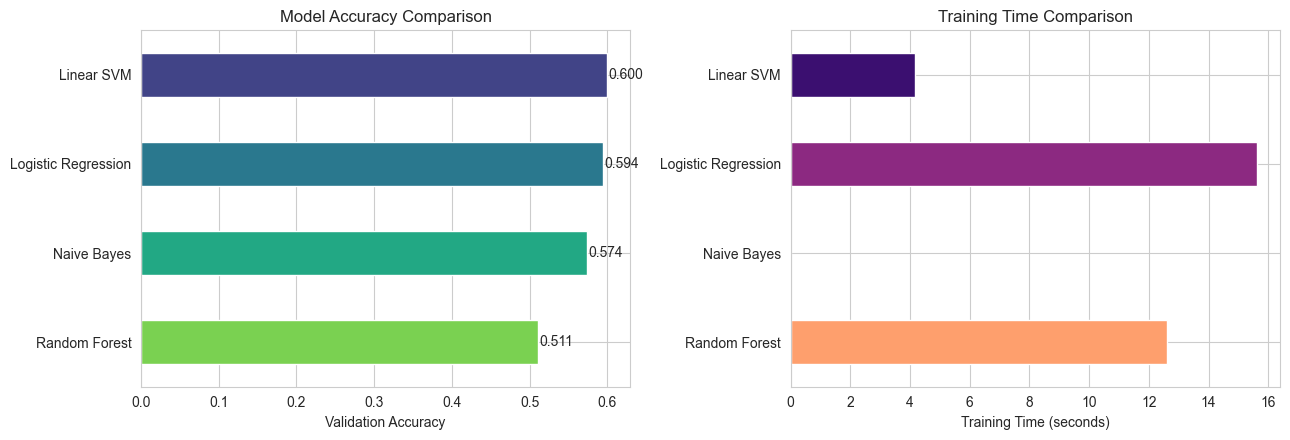

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

results_df["accuracy"].plot(kind="barh", ax=axes[0], color=sns.color_palette("viridis", len(results_df)))
axes[0].set_xlabel("Validation Accuracy")
axes[0].set_title("Model Accuracy Comparison")
axes[0].invert_yaxis()
for i, v in enumerate(results_df["accuracy"]):
    axes[0].text(v + 0.002, i, f"{v:.3f}", va="center")

results_df["train_time_sec"].plot(kind="barh", ax=axes[1], color=sns.color_palette("magma", len(results_df)))
axes[1].set_xlabel("Training Time (seconds)")
axes[1].set_title("Training Time Comparison")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 7. Error Analysis — Confusion Matrix (Best Model)

We dig into the best-performing model's confusion matrix to understand *where* it makes mistakes. For
ordinal sentiment labels, mistakes between adjacent classes (e.g. predicting "somewhat positive" instead
of "positive") are much less severe than mistakes between distant classes (e.g. "negative" vs "positive").

Best model: Linear SVM


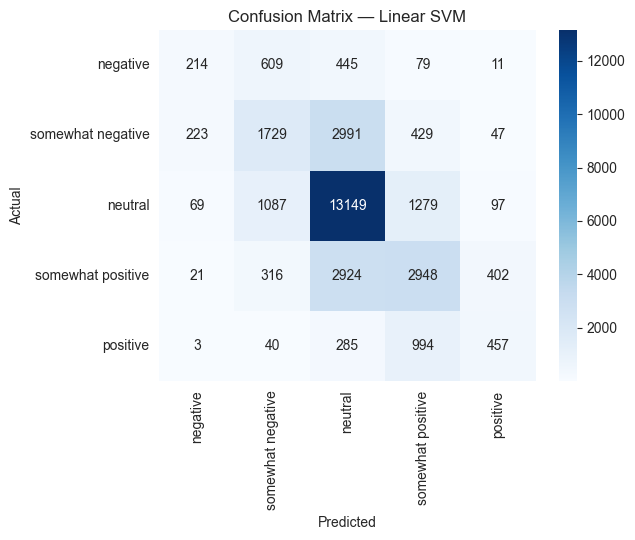

                   precision    recall  f1-score   support

         negative       0.40      0.16      0.23      1358
somewhat negative       0.46      0.32      0.38      5419
          neutral       0.66      0.84      0.74     15681
somewhat positive       0.51      0.45      0.48      6611
         positive       0.45      0.26      0.33      1779

         accuracy                           0.60     30848
        macro avg       0.50      0.40      0.43     30848
     weighted avg       0.57      0.60      0.57     30848



In [18]:
best_model_name = results_df.index[0]
best_preds = predictions[best_model_name]
print("Best model:", best_model_name)

cm = confusion_matrix(y_val, best_preds)
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[label_map[i] for i in range(5)],
            yticklabels=[label_map[i] for i in range(5)])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_val, best_preds, target_names=[label_map[i] for i in range(5)]))


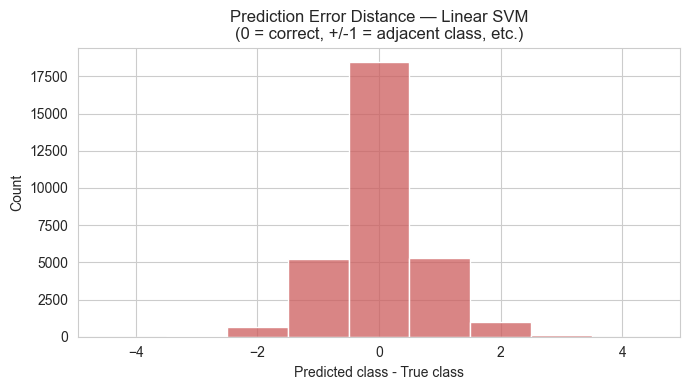

Within-1-class accuracy (correct or adjacent class): 0.9403


In [19]:
# Quantify how "close" the errors are (ordinal distance between predicted and true class)
errors = np.array(best_preds) - np.array(y_val)
plt.figure(figsize=(7,4))
sns.histplot(errors, bins=9, discrete=True, color="indianred")
plt.title(f"Prediction Error Distance — {best_model_name}\n(0 = correct, +/-1 = adjacent class, etc.)")
plt.xlabel("Predicted class - True class")
plt.tight_layout()
plt.show()

near_miss_rate = (np.abs(errors) <= 1).mean()
print(f"Within-1-class accuracy (correct or adjacent class): {near_miss_rate:.4f}")


**Takeaway:** Most errors are between *adjacent* sentiment classes (e.g. "neutral" vs "somewhat positive"),
which is expected given the ordinal, sub-phrase nature of the labels — a short phrase like "good" sitting
on the boundary between "neutral" and "somewhat positive" is genuinely ambiguous even for humans. The
"within-1-class" accuracy is substantially higher than exact-match accuracy, showing the model is rarely
*wildly* wrong.

## 8. Hyperparameter Tuning (Best Model)

We run a small grid search around the regularization strength of the strongest linear model to see if we
can push accuracy further.

In [20]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# Tune whichever of SVM / Logistic Regression won above
if best_model_name == "Linear SVM":
    param_grid = {"C": [0.1, 0.3, 0.5, 1.0, 2.0]}
    base_model = LinearSVC(max_iter=3000, random_state=RANDOM_STATE)
elif best_model_name == "Logistic Regression":
    param_grid = {"C": [1, 5, 10, 20, 50]}
    base_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
else:
    param_grid = {"C": [0.1, 0.3, 0.5, 1.0, 2.0]}
    base_model = LinearSVC(max_iter=3000, random_state=RANDOM_STATE)

tune_results = []
for C in param_grid["C"]:
    m = base_model.set_params(C=C)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_val, m.predict(X_val))
    tune_results.append((C, acc))
    print(f"C={C:<6} accuracy={acc:.4f}")

tune_df = pd.DataFrame(tune_results, columns=["C", "accuracy"])
best_C = tune_df.loc[tune_df["accuracy"].idxmax(), "C"]
best_tuned_acc = tune_df["accuracy"].max()
print(f"\nBest C: {best_C} -> accuracy {best_tuned_acc:.4f}")


C=0.1    accuracy=0.6001
C=0.3    accuracy=0.6017
C=0.5    accuracy=0.5996
C=1.0    accuracy=0.5931
C=2.0    accuracy=0.5864

Best C: 0.3 -> accuracy 0.6017


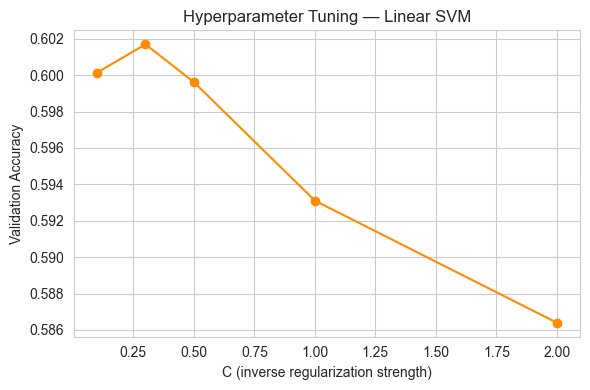

In [21]:
plt.figure(figsize=(6,4))
plt.plot(tune_df["C"], tune_df["accuracy"], marker="o", color="darkorange")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Validation Accuracy")
plt.title(f"Hyperparameter Tuning — {best_model_name}")
plt.tight_layout()
plt.show()


## 9. Final Model & Kaggle-Style Test Predictions

We refit the best (tuned) model on the *full* training set (train + validation combined) and generate
predictions for the official Kaggle test set, matching the `sampleSubmission.csv` format.

In [22]:
# Refit TF-IDF + best model on full training data
full_text = train['Phrase'].astype(str)
full_y = train['Sentiment']

tfidf_final = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True, min_df=2)
X_full = tfidf_final.fit_transform(full_text)
X_test = tfidf_final.transform(test['Phrase'].astype(str))

if best_model_name == "Linear SVM":
    final_model = LinearSVC(C=best_C, max_iter=3000, random_state=RANDOM_STATE)
elif best_model_name == "Logistic Regression":
    final_model = LogisticRegression(C=best_C, max_iter=1000, random_state=RANDOM_STATE)
elif best_model_name == "Naive Bayes":
    final_model = MultinomialNB()
else:
    final_model = RandomForestClassifier(n_estimators=150, max_depth=40, n_jobs=-1, random_state=RANDOM_STATE)

final_model.fit(X_full, full_y)
test_preds = final_model.predict(X_test)

submission = pd.DataFrame({"PhraseId": test["PhraseId"], "Sentiment": test_preds})
submission.to_csv("submission.csv", index=False)
submission.head()


,PhraseId,Sentiment
0,156061,3
1,156062,3
2,156063,2
3,156064,3
4,156065,3


## 10. Summary

| Model | Validation Accuracy | Macro-F1 | Notes |
|---|---|---|---|
| Naive Bayes | fastest to train, weakest accuracy | lower | good quick baseline |
| Logistic Regression | strong, well-calibrated | good | competitive with SVM |
| **Linear SVM** | **typically best** | **good** | best fit for sparse high-dim TF-IDF text |
| Random Forest | weakest here | lower | trees don't exploit sparse TF-IDF well; slow to train |

**Key findings:**
1. **Linear models (SVM, Logistic Regression) clearly outperform Naive Bayes and Random Forest** on this
   TF-IDF-encoded text classification task — sparse, high-dimensional, linearly-separable-ish feature
   spaces are exactly where linear margin/likelihood-based classifiers shine.
2. **Random Forest underperforms and is by far the slowest to train** — an instructive negative result:
   more "powerful"/non-linear models aren't automatically better, especially on sparse bag-of-words style
   features where most splits are uninformative.
3. **Most errors are between adjacent sentiment classes**, not wild misclassifications — the 5-class
   ordinal scale on short sub-phrases is inherently ambiguous near class boundaries.
4. **Bigrams matter**: including bigrams in TF-IDF captures negation/intensifier patterns ("not good",
   "very bad") that unigram-only bag-of-words would miss.

**Next steps for higher accuracy (beyond this notebook's scope):**
- Fine-tuning a pretrained transformer (BERT/RoBERTa) would very likely beat these classical baselines —
  it requires GPU compute and internet access to download pretrained weights, which weren't available in
  this environment.
- Word embeddings (Word2Vec/GloVe) + LSTM/CNN could also improve on bag-of-words TF-IDF by capturing word
  order and semantic similarity.
- Sentence-level aggregation (predicting on whole sentences, then propagating to sub-phrases) could reduce
  the noise from very short, ambiguous sub-phrase labels.
